In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
matches = pd.read_csv('ipl_dashboard_final.csv')
matches['date'] = pd.to_datetime(matches['date'])
print(matches.shape)
print(matches.columns.tolist()) 



(1090, 23)
['id', 'season', 'city', 'date', 'match_type', 'player_of_match', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'target_runs', 'target_overs', 'super_over', 'method', 'umpire1', 'umpire2', 'toss_won_match', 'temperature', 'rainfall']


In [3]:
matches['team1']=matches['team1'].str.replace('Delhi Daredevils','Delhi Capitals')
matches['team2']=matches['team2'].str.replace('Delhi Daredevils','Delhi Capitals')
matches['toss_winner']=matches['toss_winner'].str.replace('Delhi Daredevils','Delhi Capitals')
matches['winner']=matches['winner'].str.replace('Delhi Daredevils','Delhi Capitals')

matches['team1']=matches['team1'].str.replace('Kings XI Punjab','Punjab Kings')
matches['team2']=matches['team2'].str.replace('Kings XI Punjab','Punjab Kings')
matches['toss_winner']=matches['toss_winner'].str.replace('Kings XI Punjab','Punjab Kings')
matches['winner']=matches['winner'].str.replace('Kings XI Punjab','Punjab Kings')

matches['team1'] = matches['team1'].str.replace(r'Rising Pune Supergiant\b', 'Rising Pune Supergiants', regex=True)
matches['team2'] = matches['team2'].str.replace(r'Rising Pune Supergiant\b', 'Rising Pune Supergiants', regex=True)
matches['toss_winner'] = matches['toss_winner'].str.replace(r'Rising Pune Supergiant\b', 'Rising Pune Supergiants', regex=True)
matches['winner'] = matches['winner'].str.replace(r'Rising Pune Supergiant\b', 'Rising Pune Supergiants', regex=True)



matches['team1']=matches['team1'].str.replace('Lucknow Super Giantss','Lucknow Super Giants')
matches['team2']=matches['team2'].str.replace('Lucknow Super Giantss','Lucknow Super Giants')
matches['toss_winner']=matches['toss_winner'].str.replace('Lucknow Super Giantss','Lucknow Super Giants')
matches['winner']=matches['winner'].str.replace('Lucknow Super Giantss','Lucknow Super Giants')

matches['team1']=matches['team1'].str.replace('Royal Challengers Bangalore','Royal Challengers Bengaluru')
matches['team2']=matches['team2'].str.replace('Royal Challengers Bangalore','Royal Challengers Bengaluru')
matches['toss_winner']=matches['toss_winner'].str.replace('Royal Challengers Bangalore','Royal Challengers Bengaluru')
matches['winner']=matches['winner'].str.replace('Royal Challengers Bangalore','Royal Challengers Bengaluru')

matches['team1']=matches['team1'].str.replace('Kings XI Punjab','Punjab Kings')
matches['team2']=matches['team2'].str.replace('Kings XI Punjab','Punjab Kings')
matches['toss_winner']=matches['toss_winner'].str.replace('Kings XI Punjab','Punjab Kings')
matches['winner']=matches['winner'].str.replace('Kings XI Punjab','Punjab Kings')


print(sorted(matches['team1'].unique()))

['Chennai Super Kings', 'Deccan Chargers', 'Delhi Capitals', 'Gujarat Lions', 'Gujarat Titans', 'Kochi Tuskers Kerala', 'Kolkata Knight Riders', 'Lucknow Super Giants', 'Mumbai Indians', 'Pune Warriors', 'Punjab Kings', 'Rajasthan Royals', 'Rising Pune Supergiants', 'Royal Challengers Bengaluru', 'Sunrisers Hyderabad']


In [4]:
matches['season'] = matches['season'].astype(str)
matches['season']=matches['season'].str.replace('2007/08','2008')
matches['season']=matches['season'].str.replace('2009/10','2010')
matches['season']=matches['season'].str.replace('2020/21','2020')


In [5]:
matches=matches[matches['winner'].notna()]
print(matches.shape)


(1090, 23)


In [6]:
matches.head()


,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,...,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2,toss_won_match,temperature,rainfall
0,335982,2008,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bengaluru,Kolkata Knight Riders,Royal Challengers Bengaluru,...,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen,False,33.3,0.0
1,335983,2008,Chandigarh,2008-04-19,League,MEK Hussey,Punjab Cricket Association Stadium,Punjab Kings,Chennai Super Kings,Chennai Super Kings,...,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri,True,36.0,0.0
2,335984,2008,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Capitals,Rajasthan Royals,Rajasthan Royals,...,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar,False,38.0,0.0
3,335985,2008,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bengaluru,Mumbai Indians,...,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper,False,33.8,0.0
4,335986,2008,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,...,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan,False,38.2,0.0


In [7]:
matches.tail(5)

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,...,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2,toss_won_match,temperature,rainfall
1085,1426307,2024,Hyderabad,2024-05-19,League,Abhishek Sharma,Rajiv Gandhi International Stadium,Punjab Kings,Sunrisers Hyderabad,Punjab Kings,...,4.0,215.0,20.0,N,NaN,Nitin Menon,VK Sharma,False,32.8,9.0
1086,1426309,2024,Ahmedabad,2024-05-21,Qualifier 1,MA Starc,Narendra Modi Stadium,Sunrisers Hyderabad,Kolkata Knight Riders,Sunrisers Hyderabad,...,8.0,160.0,20.0,N,NaN,AK Chaudhary,R Pandit,False,45.2,0.0
1087,1426310,2024,Ahmedabad,2024-05-22,Eliminator,R Ashwin,Narendra Modi Stadium,Royal Challengers Bengaluru,Rajasthan Royals,Rajasthan Royals,...,4.0,173.0,20.0,N,NaN,KN Ananthapadmanabhan,MV Saidharshan Kumar,True,45.9,0.0
1088,1426311,2024,Chennai,2024-05-24,Qualifier 2,Shahbaz Ahmed,MA Chidambaram Stadium,Sunrisers Hyderabad,Rajasthan Royals,Rajasthan Royals,...,36.0,176.0,20.0,N,NaN,Nitin Menon,VK Sharma,False,36.1,0.0
1089,1426312,2024,Chennai,2024-05-26,Final,MA Starc,MA Chidambaram Stadium,Sunrisers Hyderabad,Kolkata Knight Riders,Sunrisers Hyderabad,...,8.0,114.0,20.0,N,NaN,J Madanagopal,Nitin Menon,False,39.0,0.6


In [8]:
matches.isnull().sum()#ye likha hai dekhne ke liye ki hmare data m kya duplicates ya missing values hai

id                    0
season                0
city                  0
date                  0
match_type            0
player_of_match       0
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                0
result                0
result_margin         0
target_runs           0
target_overs          0
super_over            0
method             1069
umpire1               0
umpire2               0
toss_won_match        0
temperature           0
rainfall              0
dtype: int64

In [9]:
print(matches['city'].isnull())  #iska use next string m kiya

0       False
1       False
2       False
3       False
4       False
        ...  
1085    False
1086    False
1087    False
1088    False
1089    False
Name: city, Length: 1090, dtype: bool


In [10]:
print(matches[matches['city'].isnull()][['venue','city',]])

Empty DataFrame
Columns: [venue, city]
Index: []


In [11]:
matches.loc[matches['venue']=='Sharjah Cricket Stadium','city']='Sharjah' #matches.loc[ condition, 'city' ] = 'value'
matches.loc[matches['venue']=='Dubai International Cricket Stadium','city']='Dubai'

matches['city']=matches['city'].str.replace('Bengaluru','Bangalore')
matches['city']=matches['city'].str.replace('Navi Mumbai','Mumbai')
print(matches['city'].isnull().sum())

0


In [12]:
matches['result_margin']=matches['result_margin'].fillna(0)

In [13]:
matches['toss_won_match']=matches['toss_winner']==matches['winner']

In [14]:
print(matches['toss_won_match'].mean())#for simple form
print(matches['toss_won_match'].mean()*100)#for percentage form

0.5082568807339449
50.825688073394495


In [15]:
print(matches.groupby('season')['toss_won_match'].mean())

season
2008    0.482759
2009    0.578947
2010    0.516667
2011    0.527778
2012    0.445946
2013    0.473684
2014    0.500000
2015    0.491228
2016    0.566667
2017    0.576271
2018    0.533333
2019    0.610169
2021    0.500000
2022    0.486486
2023    0.465753
2024    0.436620
Name: toss_won_match, dtype: float64


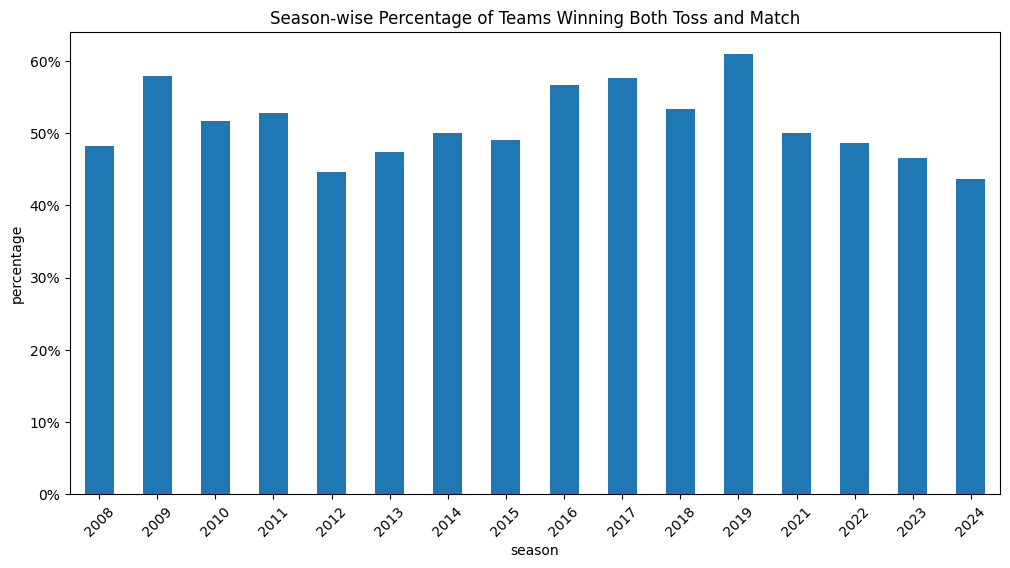

In [16]:
toss_by_season=matches.groupby('season')['toss_won_match'].mean()
plt.figure(figsize=(12,6))
toss_by_season.plot(kind='bar')
plt.title('Season-wise Percentage of Teams Winning Both Toss and Match')#jisne toss bhi jeeta or match bhii season wise
plt.ylabel('percentage')
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.0f}%'))
plt.show()

In [17]:
print(matches['toss_decision'].unique())

<ArrowStringArray>
['field', 'bat']
Length: 2, dtype: str


toss_decision
bat      0.453846
field    0.538571
Name: toss_won_match, dtype: float64


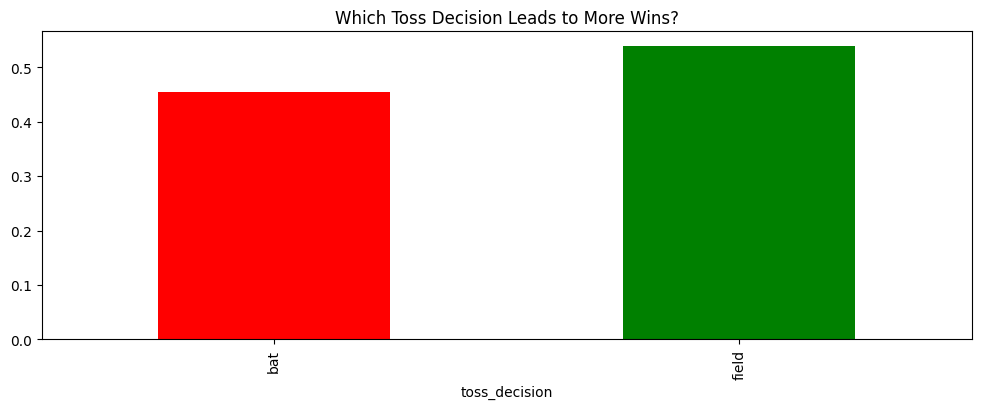

In [18]:
toss_choose_field=matches.groupby('toss_decision')['toss_won_match'].mean()
print(toss_choose_field)
plt.figure(figsize=(12,4))
toss_choose_field.plot(kind='bar',color=['red','green'])
plt.title('Which Toss Decision Leads to More Wins?')
plt.show()

In [19]:
 matches['venue']=matches['venue'].str.split(',').str[0].str.replace('M.Chinnaswamy Stadium', 'M Chinnaswamy Stadium')


In [20]:
matches['date']=pd.to_datetime(matches['date'],errors='coerce')
matches['venue']=matches['venue'].astype(str)

In [21]:
print(matches.groupby('venue')['toss_won_match'].mean())

venue
Arun Jaitley Stadium                                            0.466667
Barabati Stadium                                                0.714286
Barsapara Cricket Stadium                                       0.000000
Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium    0.615385
Brabourne Stadium                                               0.518519
Buffalo Park                                                    0.666667
De Beers Diamond Oval                                           0.666667
Dr DY Patil Sports Academy                                      0.540541
Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium             0.533333
Dubai International Cricket Stadium                             0.391304
Eden Gardens                                                    0.526882
Feroz Shah Kotla                                                0.525424
Green Park                                                      1.000000
Himachal Pradesh Cricket Association Stadium 

In [22]:
venue_count=matches.groupby('venue')['toss_won_match'].count()
print(venue_count)

venue
Arun Jaitley Stadium                                             30
Barabati Stadium                                                  7
Barsapara Cricket Stadium                                         3
Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium     13
Brabourne Stadium                                                27
Buffalo Park                                                      3
De Beers Diamond Oval                                             3
Dr DY Patil Sports Academy                                       37
Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium              15
Dubai International Cricket Stadium                              46
Eden Gardens                                                     93
Feroz Shah Kotla                                                 59
Green Park                                                        4
Himachal Pradesh Cricket Association Stadium                     13
Holkar Cricket Stadium                    

In [23]:
popular_venue=venue_count[venue_count>20]
print(popular_venue)

venue
Arun Jaitley Stadium                             30
Brabourne Stadium                                27
Dr DY Patil Sports Academy                       37
Dubai International Cricket Stadium              46
Eden Gardens                                     93
Feroz Shah Kotla                                 59
M Chinnaswamy Stadium                            91
MA Chidambaram Stadium                           85
Maharashtra Cricket Association Stadium          35
Narendra Modi Stadium                            24
Punjab Cricket Association IS Bindra Stadium     26
Punjab Cricket Association Stadium               35
Rajiv Gandhi International Stadium               77
Sawai Mansingh Stadium                           57
Sharjah Cricket Stadium                          28
Sheikh Zayed Stadium                             29
Wankhede Stadium                                118
Name: toss_won_match, dtype: int64


In [24]:
venue_toss = matches.groupby('venue')['toss_won_match'].mean().sort_values(ascending=False).head(20)
print(venue_toss)

venue
Green Park                                                      1.000000
OUTsurance Oval                                                 1.000000
Holkar Cricket Stadium                                          0.777778
Barabati Stadium                                                0.714286
De Beers Diamond Oval                                           0.666667
SuperSport Park                                                 0.666667
Buffalo Park                                                    0.666667
Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium    0.615385
Kingsmead                                                       0.600000
Newlands                                                        0.571429
Sharjah Cricket Stadium                                         0.571429
JSCA International Stadium Complex                              0.571429
Subrata Roy Sahara Stadium                                      0.562500
Maharashtra Cricket Association Stadium      

In [25]:
venue_toss = matches.groupby('venue')['toss_won_match'].mean()
#Step 2 — Venue wise match count nikalo
venue_count = matches.groupby('venue')['toss_won_match'].count()
#Step 3 — Sirf popular venues rakho
popular_venues = venue_count[venue_count > 10]
#Step 4 — Combine karo
venue_toss = venue_toss[popular_venues.index]
#Step 5 — Sort karo aur top 10 dekho
venue_toss = venue_toss.sort_values(ascending=False).head(10)
print(venue_toss)
matches.head()

venue
SuperSport Park                                                 0.666667
Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium    0.615385
Kingsmead                                                       0.600000
Sharjah Cricket Stadium                                         0.571429
Subrata Roy Sahara Stadium                                      0.562500
Maharashtra Cricket Association Stadium                         0.542857
Dr DY Patil Sports Academy                                      0.540541
M Chinnaswamy Stadium                                           0.538462
Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium             0.533333
Eden Gardens                                                    0.526882
Name: toss_won_match, dtype: float64


,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,...,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2,toss_won_match,temperature,rainfall
0,335982,2008,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bengaluru,Kolkata Knight Riders,Royal Challengers Bengaluru,...,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen,False,33.3,0.0
1,335983,2008,Chandigarh,2008-04-19,League,MEK Hussey,Punjab Cricket Association Stadium,Punjab Kings,Chennai Super Kings,Chennai Super Kings,...,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri,True,36.0,0.0
2,335984,2008,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Capitals,Rajasthan Royals,Rajasthan Royals,...,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar,False,38.0,0.0
3,335985,2008,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bengaluru,Mumbai Indians,...,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper,False,33.8,0.0
4,335986,2008,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,...,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan,False,38.2,0.0


venue
Maharaja Yadavindra Singh International Cricket Stadium          4.200000
Green Park                                                       5.500000
Vidarbha Cricket Association Stadium                             7.000000
New Wanderers Stadium                                            7.500000
Shaheed Veer Narayan Singh International Stadium                 7.666667
JSCA International Stadium Complex                               9.285714
Holkar Cricket Stadium                                           9.888889
OUTsurance Oval                                                 10.000000
SuperSport Park                                                 10.833333
Punjab Cricket Association IS Bindra Stadium                    11.538462
Saurashtra Cricket Association Stadium                          11.800000
Kingsmead                                                       12.800000
Barabati Stadium                                                13.285714
Zayed Cricket Stadium           

C:\Users\rohit\AppData\Local\Temp\ipykernel_13892\1943647690.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=venuess.values,y=venuess.index,palette='flare')
c:\Users\rohit\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127967 (\N{STADIUM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


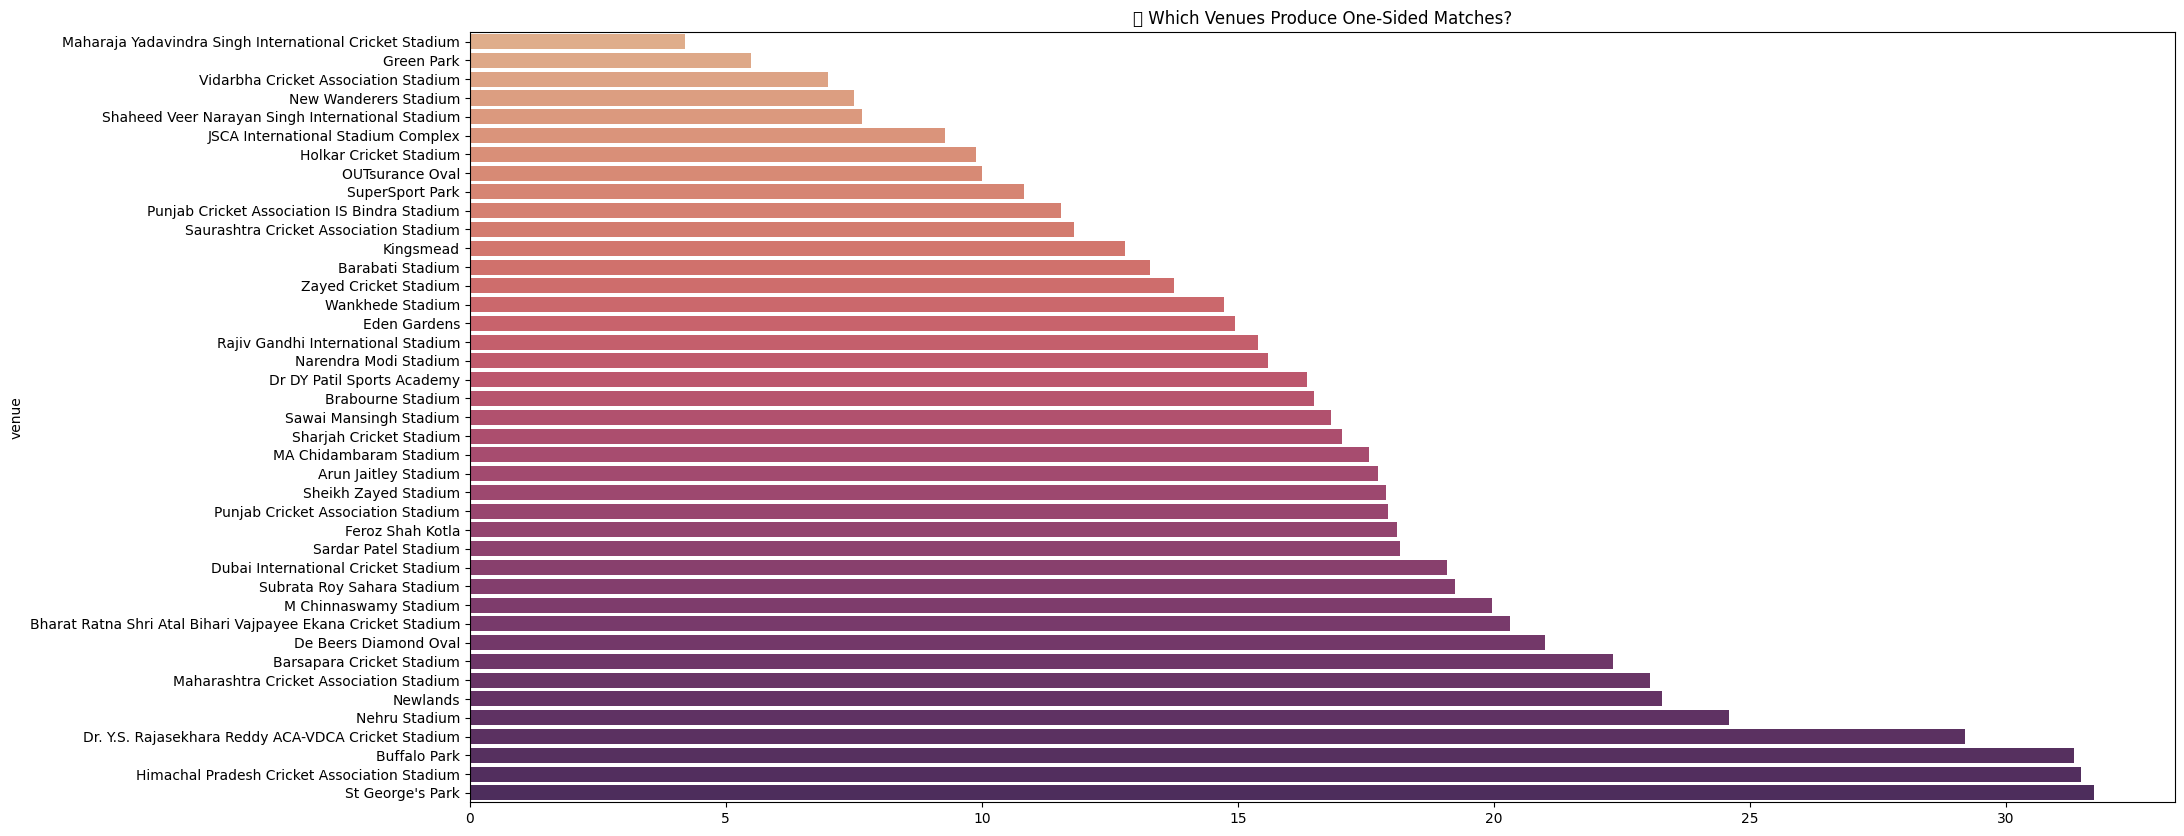

In [26]:
venuess=matches.groupby('venue')['result_margin'].mean().sort_values()
print(venuess)
plt.figure(figsize=(22,10))
sns.barplot(x=venuess.values,y=venuess.index,palette='flare')
plt.title("🏟️ Which Venues Produce One-Sided Matches?")
plt.show()


venue
Wankhede Stadium                       118
Eden Gardens                            93
M Chinnaswamy Stadium                   91
MA Chidambaram Stadium                  85
Rajiv Gandhi International Stadium      77
Feroz Shah Kotla                        59
Sawai Mansingh Stadium                  57
Dubai International Cricket Stadium     46
Dr DY Patil Sports Academy              37
Punjab Cricket Association Stadium      35
Name: count, dtype: int64


C:\Users\rohit\AppData\Local\Temp\ipykernel_13892\3498755279.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=venues.values,y=venues.index,palette='rocket')


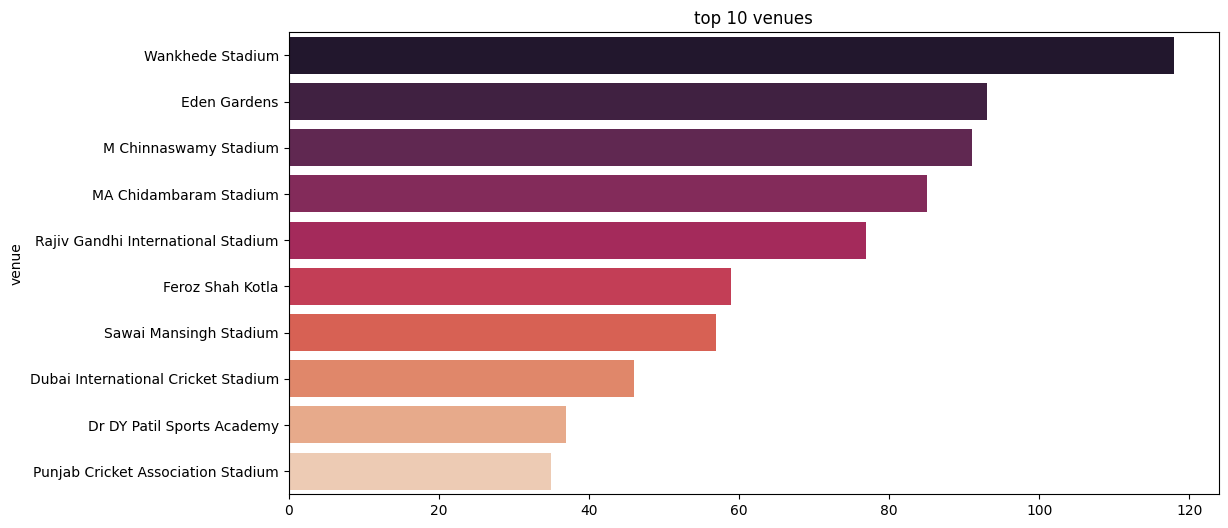

In [27]:
venues=matches['venue'].value_counts().head(10)
print(venues)
plt.figure(figsize=(12,6))
sns.barplot(x=venues.values,y=venues.index,palette='rocket')
plt.title('top 10 venues')
plt.show()
    

player_of_match
AB de Villiers    25
CH Gayle          22
RG Sharma         19
DA Warner         18
V Kohli           18
MS Dhoni          17
SR Watson         16
YK Pathan         16
RA Jadeja         16
SP Narine         15
Name: count, dtype: int64


C:\Users\rohit\AppData\Local\Temp\ipykernel_13892\3821554688.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot( x=top_players.values, y=top_players.index,palette='viridis')


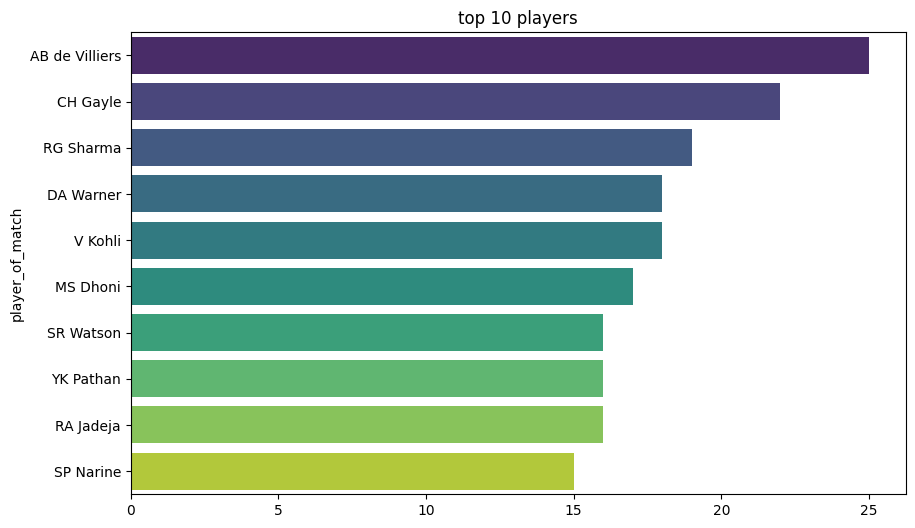

In [28]:
top_players=matches['player_of_match'].value_counts().head(10).sort_values(ascending=False)
print(top_players)
plt.figure(figsize=(10,6))


sns.barplot( x=top_players.values, y=top_players.index,palette='viridis')
# top_players.plot(kind='barh',color='purple')
plt.title('top 10 players')
plt.show()



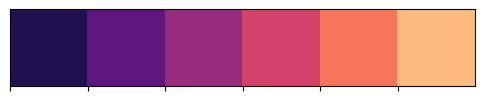

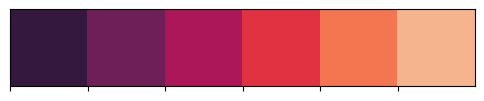

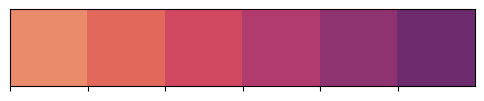

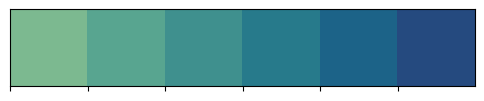

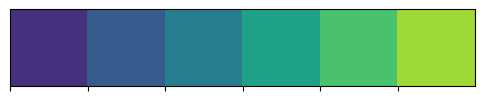

In [29]:
sns.palplot(sns.color_palette("magma"))
sns.palplot(sns.color_palette("rocket"))
sns.palplot(sns.color_palette("flare"))
sns.palplot(sns.color_palette("crest"))
sns.palplot(sns.color_palette("viridis"))

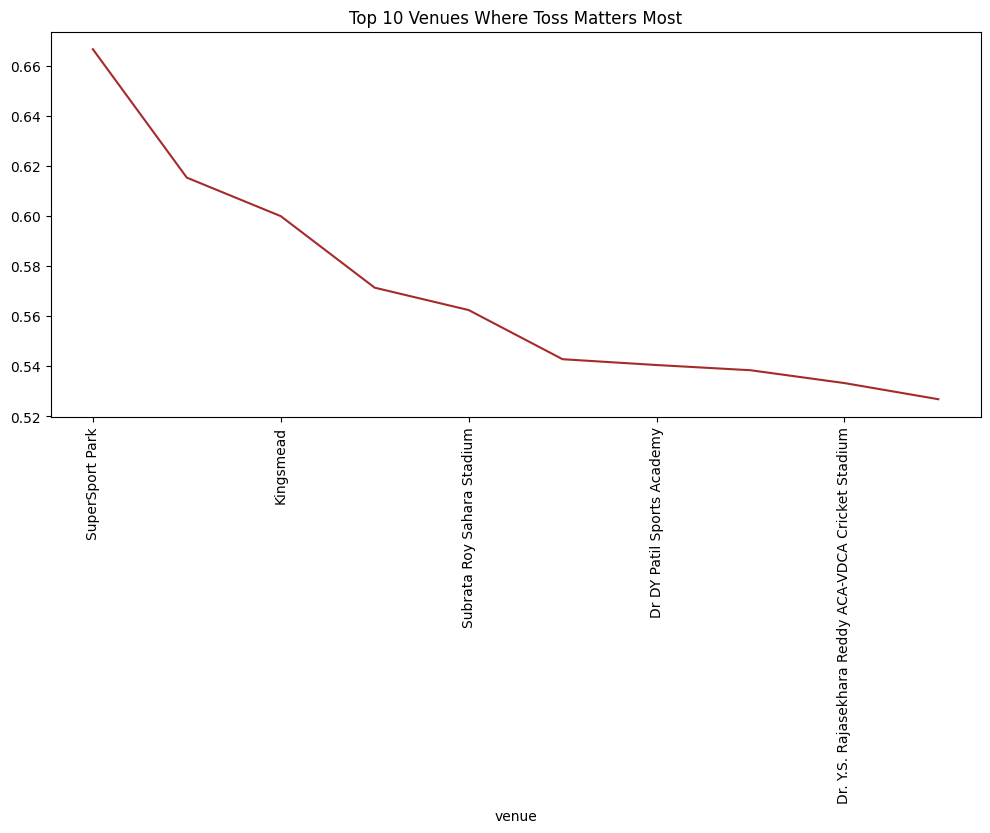

In [30]:
plt.figure(figsize=(12,5))
venue_toss.plot(kind='line',color='brown')
plt.title("Top 10 Venues Where Toss Matters Most")
plt.xticks(rotation=90)
plt.show()          

In [31]:
teamwise_analyse=matches.groupby("toss_winner")['toss_won_match'].mean().sort_values(ascending = False)
print(teamwise_analyse)


toss_winner
Gujarat Lions                  0.666667
Gujarat Titans                 0.636364
Chennai Super Kings            0.619835
Rising Pune Supergiants        0.615385
Kolkata Knight Riders          0.557377
Mumbai Indians                 0.545455
Lucknow Super Giants           0.526316
Rajasthan Royals               0.508475
Royal Challengers Bengaluru    0.508333
Kochi Tuskers Kerala           0.500000
Delhi Capitals                 0.472868
Deccan Chargers                0.441860
Sunrisers Hyderabad            0.431818
Punjab Kings                   0.412844
Pune Warriors                  0.150000
Name: toss_won_match, dtype: float64


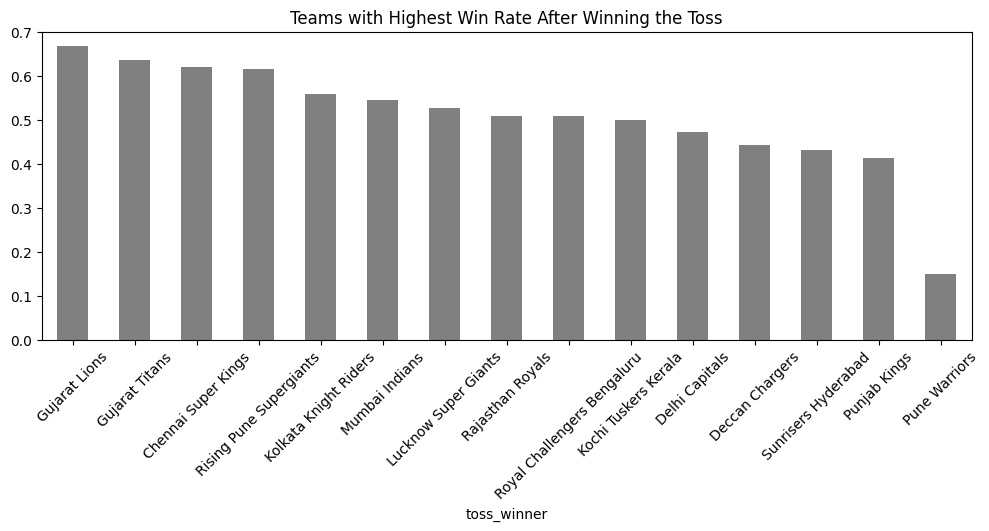

In [32]:
plt.figure(figsize=(12,4))
teamwise_analyse.plot(kind='bar', color='grey')
plt.title('Teams with Highest Win Rate After Winning the Toss')
plt.xticks(rotation=45)
plt.show()

winner
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bengaluru    123
Delhi Capitals                 115
Rajasthan Royals               112
Punjab Kings                   112
Sunrisers Hyderabad             88
Deccan Chargers                 29
Gujarat Titans                  28
Lucknow Super Giants            24
Rising Pune Supergiants         15
Gujarat Lions                   13
Pune Warriors                   12
Kochi Tuskers Kerala             6
Name: count, dtype: int64


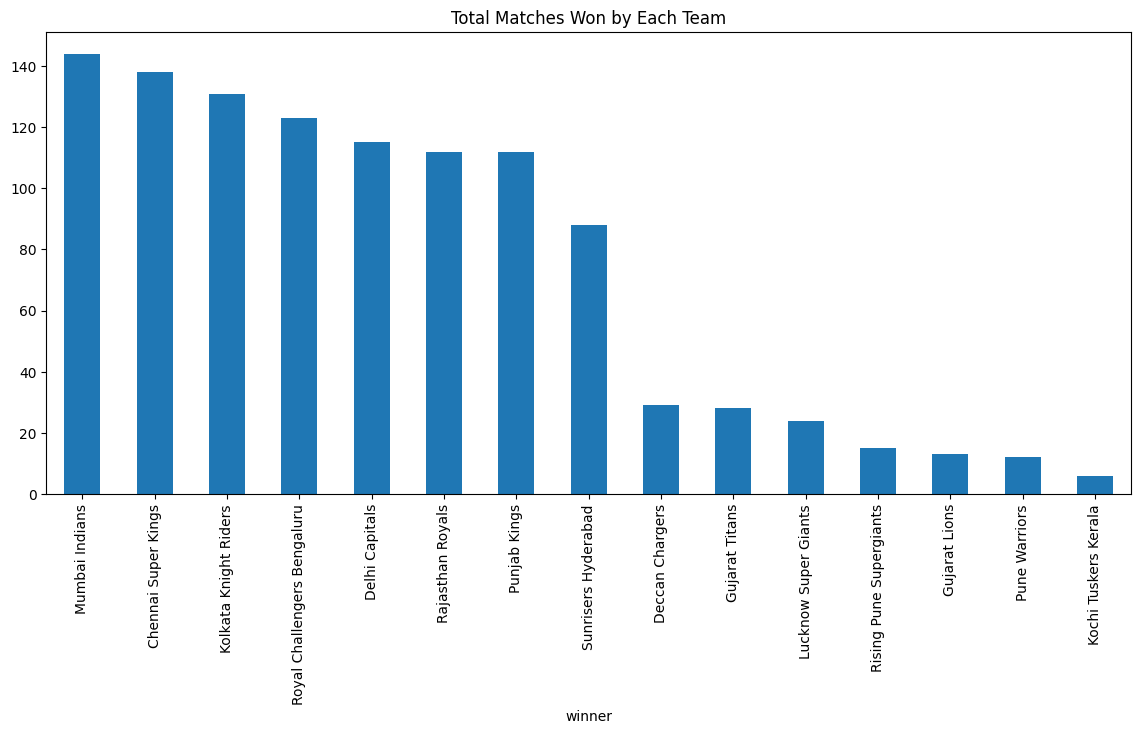

In [33]:
team=matches['winner'].value_counts()
print(team)

plt.figure(figsize=(14,6))
team.plot(kind='bar')
plt.title('Total Matches Won by Each Team')
plt.show()

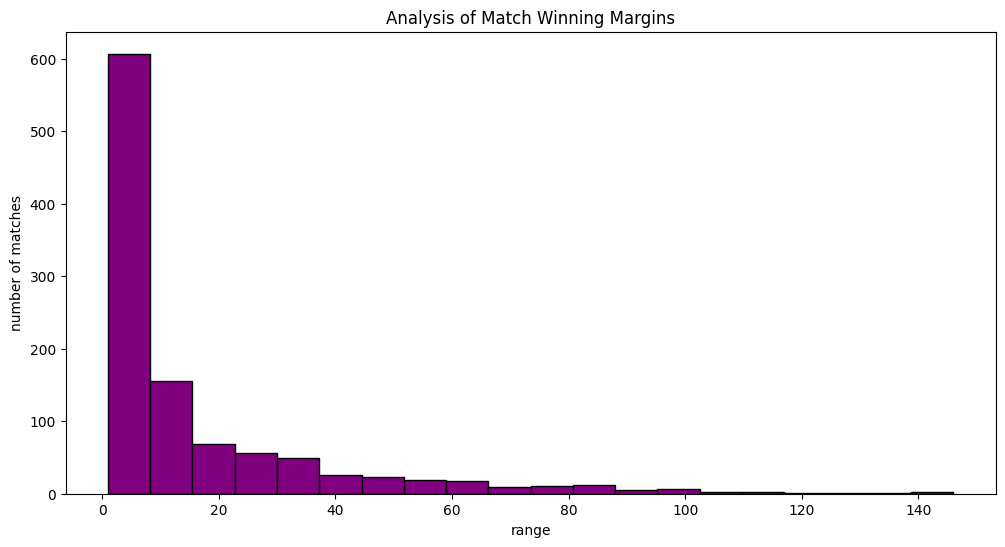

In [34]:
plt.figure(figsize=(12,6))
matches[matches['result_margin']>0]['result_margin'].plot(kind='hist',color='purple',bins=20,edgecolor='black')
plt.title('Analysis of Match Winning Margins')
plt.xlabel('range')
plt.ylabel('number of matches')
plt.show()

season
2008     58
2009     57
2010     60
2011     72
2012     74
2013     76
2014     60
2015     57
2016     60
2017     59
2018     60
2019     59
2021    120
2022     74
2023     73
2024     71
Name: team1, dtype: int64


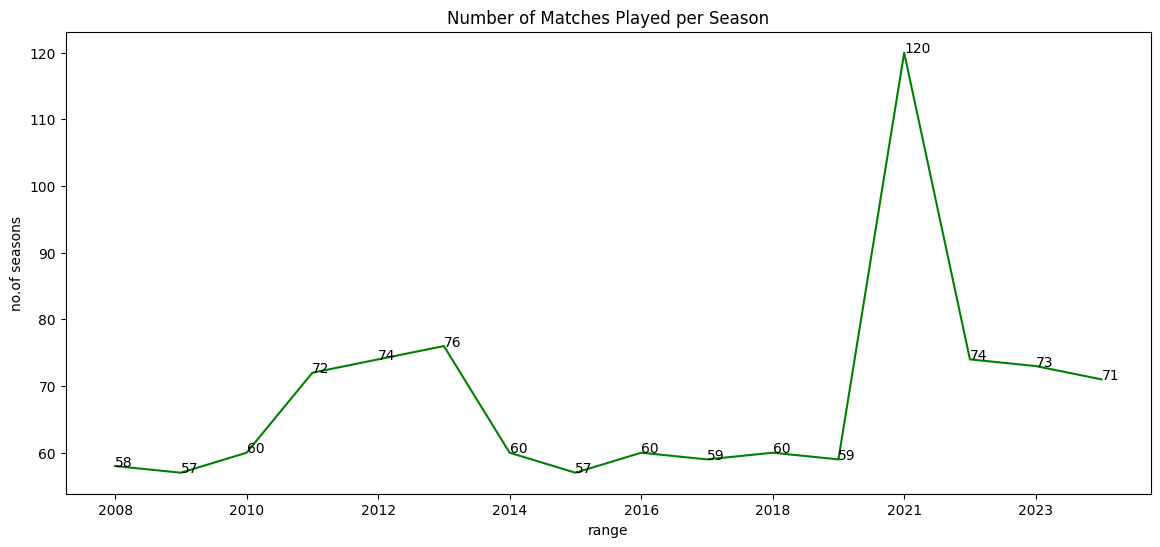

In [35]:
season_matches=matches.groupby('season')['team1'].count()
print(season_matches)
plt.figure(figsize=(14,6))
season_matches.plot(kind='line',color='green')
plt.title('Number of Matches Played per Season')
plt.xlabel('range')
plt.ylabel('no.of seasons')

for i, y in enumerate(season_matches.values):
    plt.text(i, y, str(y))
plt.show()


toss_decision
field    64.220183
bat      35.779817
Name: proportion, dtype: float64


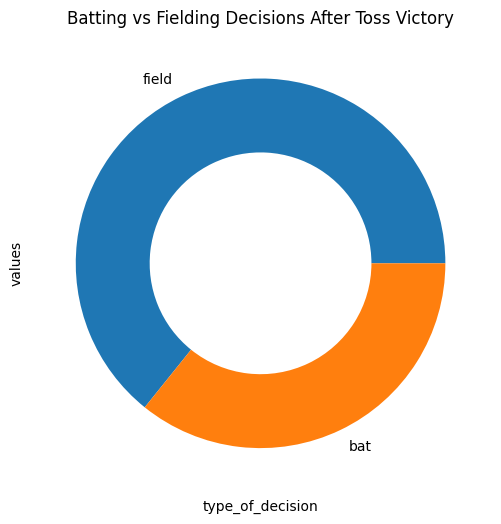

In [36]:
toss_decision_counts=matches['toss_decision'].value_counts(normalize=True)*100
print(toss_decision_counts)
plt.figure(figsize=(12,6))
toss_decision_counts.plot(kind='pie',wedgeprops=dict(width=0.4))    #donut chart
plt.title('Batting vs Fielding Decisions After Toss Victory')
plt.xlabel('type_of_decision')
plt.ylabel('values')
plt.show()

toss_won_match
False    20.807836
True     13.389892
Name: result_margin, dtype: float64


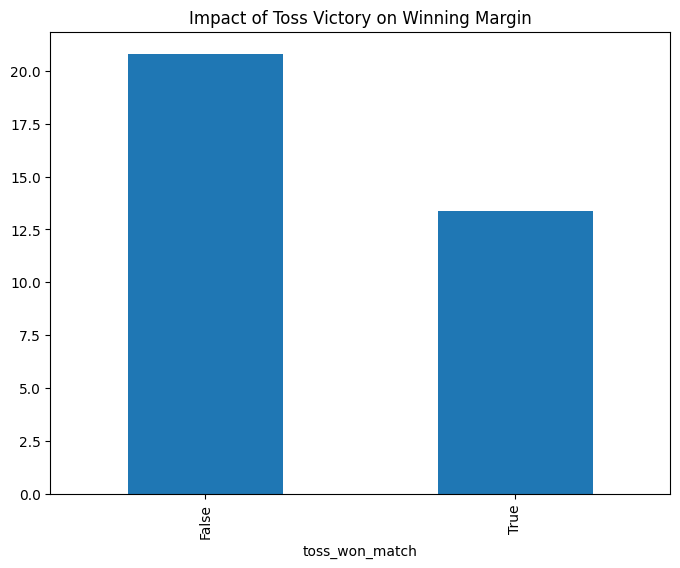

In [37]:
margin_by_toss=matches.groupby('toss_won_match')['result_margin'].mean()
print(margin_by_toss)
plt.figure(figsize=(8,6))
margin_by_toss.plot(kind='bar')
plt.title('Impact of Toss Victory on Winning Margin')
plt.show()


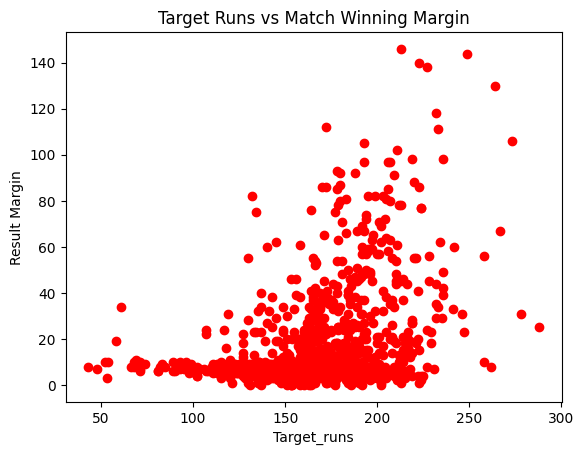

In [38]:
plt.scatter(matches['target_runs'], matches['result_margin'],color='red')
plt.xlabel('Target_runs')
plt.ylabel('Result Margin')
plt.title('Target Runs vs Match Winning Margin')
plt.show()

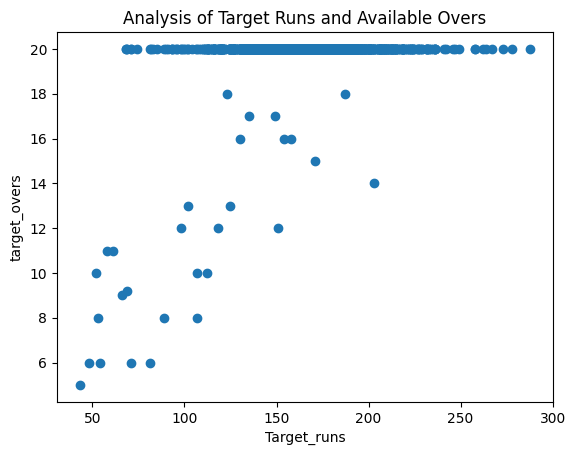

In [39]:
plt.scatter(matches['target_runs'], matches['target_overs'])
plt.xlabel('Target_runs')
plt.ylabel('target_overs')
plt.title('Analysis of Target Runs and Available Overs')
plt.show()

toss_decision                                            bat     field
venue                                                                 
Arun Jaitley Stadium                                0.500000  0.450000
Barabati Stadium                                    1.000000  0.600000
Barsapara Cricket Stadium                           0.000000  0.000000
Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cr...  0.666667  0.571429
Brabourne Stadium                                   0.555556  0.500000
Buffalo Park                                        0.666667       NaN
De Beers Diamond Oval                               0.500000  1.000000
Dr DY Patil Sports Academy                          0.500000  0.555556
Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Sta...  0.571429  0.500000
Dubai International Cricket Stadium                 0.368421  0.407407
Eden Gardens                                        0.400000  0.587302
Feroz Shah Kotla                                    0.480000  0.558824
Green 

c:\Users\rohit\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127967 (\N{STADIUM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


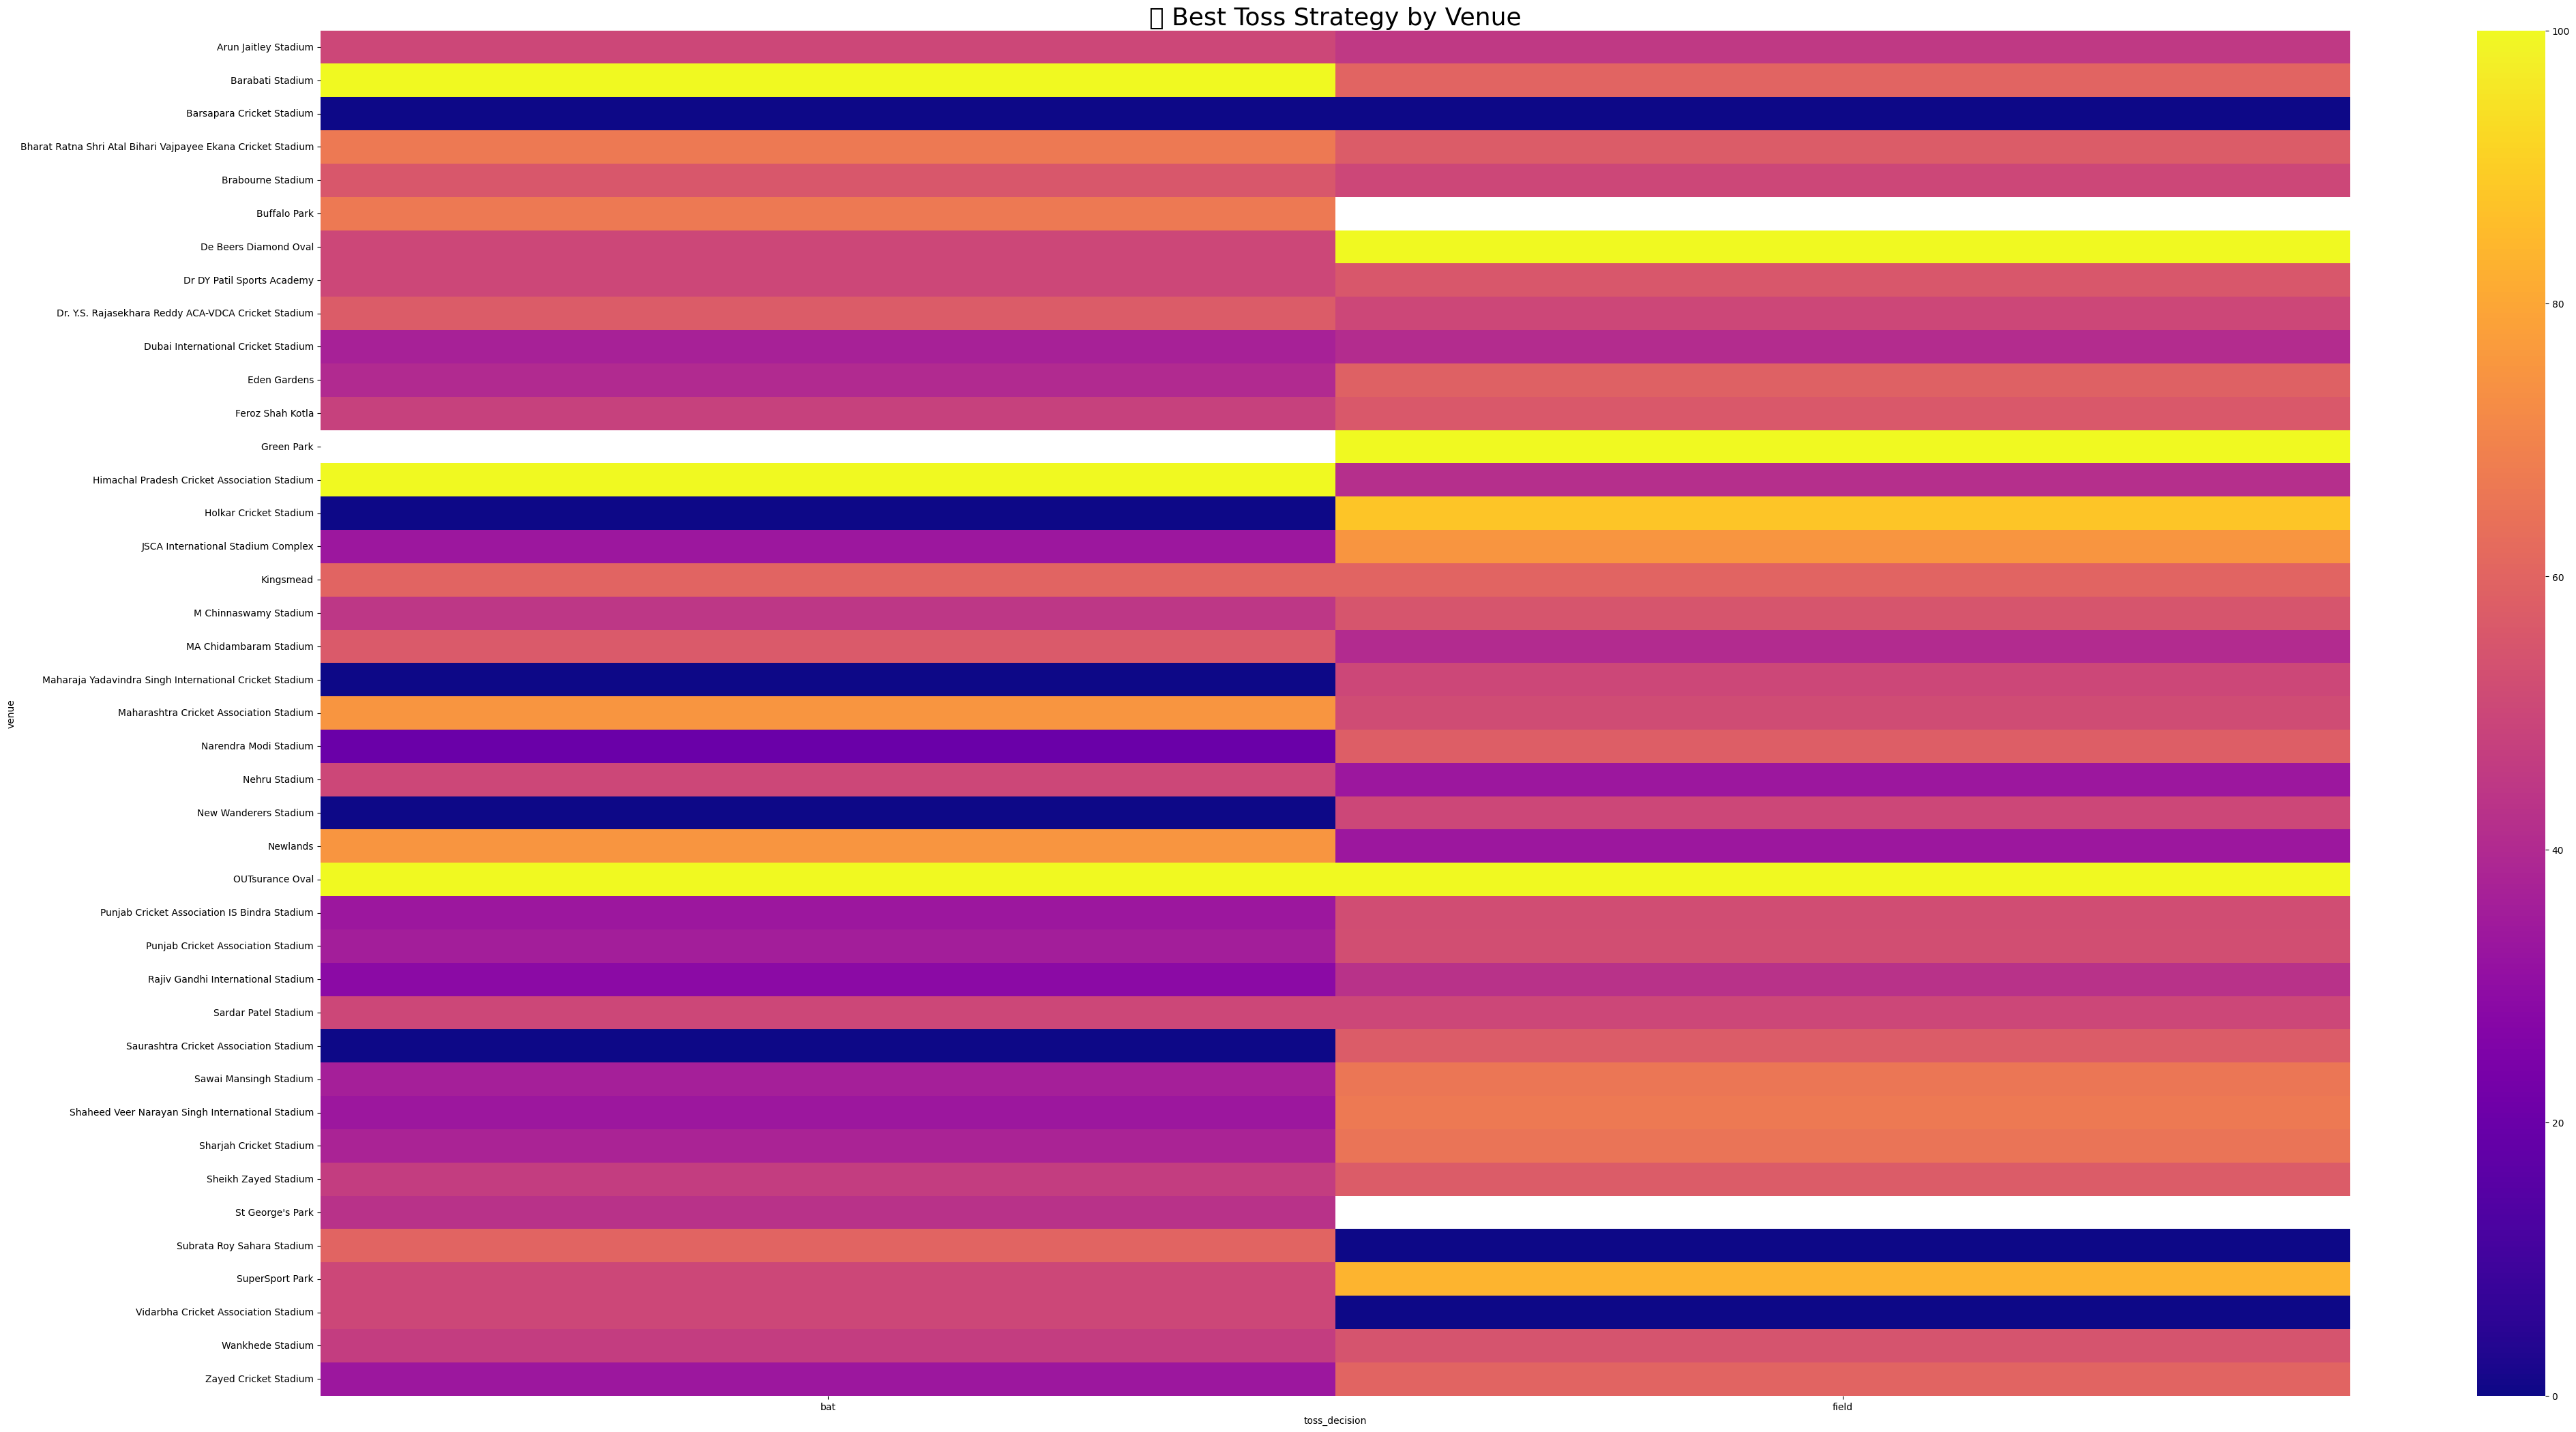

In [40]:
venue_heatmap=matches.pivot_table(
    index="venue",
    columns='toss_decision',
    values="toss_won_match",
    aggfunc="mean")
print(venue_heatmap)

plt.figure(figsize=(48,26))
sns.heatmap(venue_heatmap*100,cmap="plasma")
plt.title("🏟️ Best Toss Strategy by Venue",fontsize=26)
plt.show()

In [41]:
heatmap_data = matches.pivot_table(
    index='toss_winner', 
    columns='toss_decision', 
    values='toss_won_match', 
    aggfunc='mean'
)
print(heatmap_data)
plt.figure(figsize=(26,12))
sns.heatmap

toss_decision                     bat     field
toss_winner                                    
Chennai Super Kings          0.593220  0.645161
Deccan Chargers              0.458333  0.421053
Delhi Capitals               0.450000  0.483146
Gujarat Lions                0.000000  0.714286
Gujarat Titans               0.500000  0.687500
Kochi Tuskers Kerala         0.000000  0.800000
Kolkata Knight Riders        0.526316  0.571429
Lucknow Super Giants         0.666667  0.461538
Mumbai Indians               0.566038  0.533333
Pune Warriors                0.272727  0.000000
Punjab Kings                 0.187500  0.506494
Rajasthan Royals             0.409091  0.567568
Rising Pune Supergiants      0.000000  0.800000
Royal Challengers Bengaluru  0.485714  0.517647
Sunrisers Hyderabad          0.342857  0.490566


<function seaborn.matrix.heatmap(data, *, vmin=None, vmax=None, cmap=None, center=None, robust=False, annot=None, fmt='.2g', annot_kws=None, linewidths=0, linecolor='white', cbar=True, cbar_kws=None, cbar_ax=None, square=False, xticklabels='auto', yticklabels='auto', mask=None, ax=None, **kwargs)>

<Figure size 2600x1200 with 0 Axes>

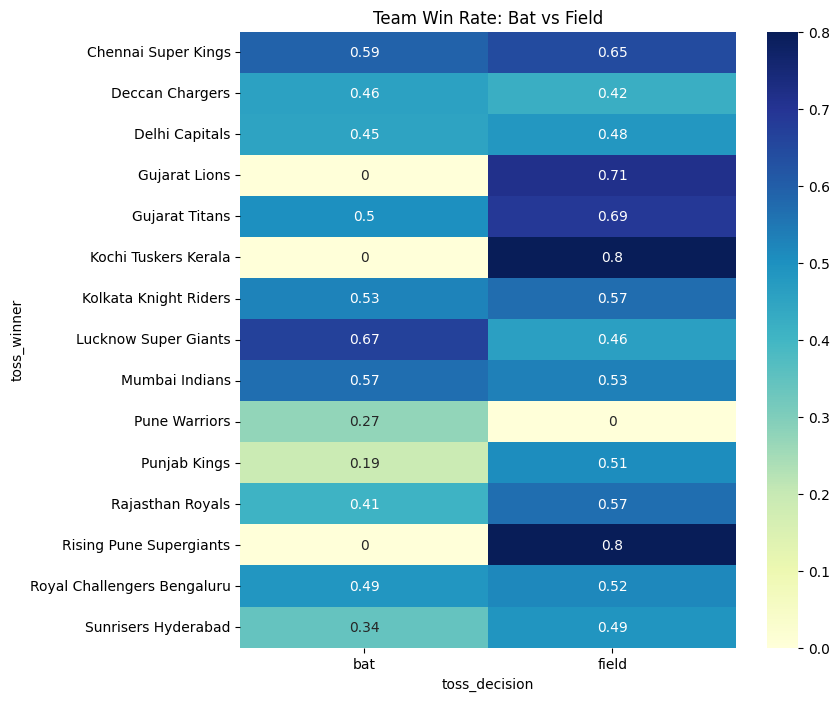

In [42]:
plt.figure(figsize=(8,8))
sns.heatmap(heatmap_data, annot=True, cmap='YlGnBu')
plt.title('Team Win Rate: Bat vs Field')
plt.show()

In [43]:
print(matches[['city','date']].head(1))

        city       date
0  Bangalore 2008-04-18


In [44]:
print(matches['city'].unique())

<ArrowStringArray>
[     'Bangalore',     'Chandigarh',          'Delhi',         'Mumbai',
        'Kolkata',         'Jaipur',      'Hyderabad',        'Chennai',
      'Cape Town', 'Port Elizabeth',         'Durban',      'Centurion',
    'East London',   'Johannesburg',      'Kimberley',   'Bloemfontein',
      'Ahmedabad',        'Cuttack',         'Nagpur',     'Dharamsala',
          'Kochi',         'Indore',  'Visakhapatnam',           'Pune',
         'Raipur',         'Ranchi',      'Abu Dhabi',        'Sharjah',
          'Dubai',         'Rajkot',         'Kanpur',        'Lucknow',
       'Guwahati',         'Mohali']
Length: 34, dtype: str


In [45]:
matches.head()
matches.info()

<class 'pandas.DataFrame'>
RangeIndex: 1090 entries, 0 to 1089
Data columns (total 23 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   id               1090 non-null   int64         
 1   season           1090 non-null   str           
 2   city             1090 non-null   str           
 3   date             1090 non-null   datetime64[us]
 4   match_type       1090 non-null   str           
 5   player_of_match  1090 non-null   str           
 6   venue            1090 non-null   str           
 7   team1            1090 non-null   str           
 8   team2            1090 non-null   str           
 9   toss_winner      1090 non-null   str           
 10  toss_decision    1090 non-null   str           
 11  winner           1090 non-null   str           
 12  result           1090 non-null   str           
 13  result_margin    1090 non-null   float64       
 14  target_runs      1090 non-null   float64       
 15

In [46]:
city_coords = {
    'Bangalore': (12.9716, 77.5946),
    'Chandigarh': (30.7333, 76.7794),
    'Delhi': (28.7041, 77.1025),
    'Mumbai': (19.0760, 72.8777),
    'Kolkata': (22.5726, 88.3639),
    'Jaipur': (26.9124, 75.7873),
    'Hyderabad': (17.3850, 78.4867),
    'Chennai': (13.0827, 80.2707),
    'Cape Town': (-33.9249, 18.4241),
    'Port Elizabeth': (-33.9608, 25.6022),
    'Durban': (-29.8587, 31.0218),
    'Centurion': (-25.8601, 28.1894),
    'East London': (-33.0153, 27.9116),
    'Johannesburg': (-26.2041, 28.0473),
    'Kimberley': (-28.7282, 24.7499),
    'Bloemfontein': (-29.0852, 26.1596),
    'Ahmedabad': (23.0225, 72.5714),
    'Cuttack': (20.4625, 85.8830),
    'Nagpur': (21.1458, 79.0882),
    'Dharamsala': (32.2190, 76.3234),
    'Kochi': (9.9312, 76.2673),
    'Indore': (22.7196, 75.8577),
    'Visakhapatnam': (17.6868, 83.2185),
    'Pune': (18.5204, 73.8567),
    'Raipur': (21.2514, 81.6296),
    'Ranchi': (23.3441, 85.3096),
    'Abu Dhabi': (24.4539, 54.3773),
    'Sharjah': (25.3463, 55.4209),
    'Dubai': (25.2048, 55.2708),
    'Rajkot': (22.3039, 70.8022),
    'Kanpur': (26.4499, 80.3319),
    'Lucknow': (26.8467, 80.9462),
    'Guwahati': (26.1445, 91.7362),
    'Mohali': (30.7046, 76.7179)
}

print(len(city_coords))

34


In [47]:
city=matches['city'].iloc[0]
date = matches['date'].iloc[0]
date_str=str(date.date())
print(city)
print(date_str)

Bangalore
2008-04-18


In [48]:
lat,lon=city_coords[city]
print(lat,lon)

12.9716 77.5946


In [49]:
import requests

In [50]:
url = "https://archive-api.open-meteo.com/v1/archive"

params = {
    "latitude": lat,
    "longitude": lon,
    "start_date": date_str,
    "end_date": date_str,
    "daily": "temperature_2m_max,precipitation_sum"
}

response = requests.get(url, params=params)
print(response.json())
data=response.json()




{'latitude': 12.970123, 'longitude': 77.56364, 'generationtime_ms': 29.56974506378174, 'utc_offset_seconds': 0, 'timezone': 'GMT', 'timezone_abbreviation': 'GMT', 'elevation': 910.0, 'daily_units': {'time': 'iso8601', 'temperature_2m_max': '°C', 'precipitation_sum': 'mm'}, 'daily': {'time': ['2008-04-18'], 'temperature_2m_max': [33.3], 'precipitation_sum': [0.0]}}


In [51]:
temp = data['daily']['temperature_2m_max'][0]
rain = data['daily']['precipitation_sum'][0]

print("Temperature:", temp)
print("Rain:", rain)

Temperature: 33.3
Rain: 0.0


In [52]:
# matches = pd.read_csv('ipl_with_weather.csv')
# matches['date'] = pd.to_datetime(matches['date'])

# temps = []
# rains = []
# for i in range(len(matches)):
#     city = matches['city'].iloc[i]
#     date = matches['date'].iloc[i]
#     temp, rain = get_weather(city, date)
#     temps.append(temp)
#     rains.append(rain)
#     print(i, city, temp, rain)

# matches['temperature'] = temps
# matches['rainfall'] = rains

In [ ]:
# matches.to_csv('ipl_final_with_weather.csv', index=False)
# print("Saved!")

In [54]:
print(matches['temperature'].describe())
print(matches['rainfall'].describe())

count    1090.000000
mean       34.665321
std         4.625067
min        11.800000
25%        32.600000
50%        35.100000
75%        37.800000
max        45.900000
Name: temperature, dtype: float64
count    1090.000000
mean        0.607339
std         2.269416
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        28.400000
Name: rainfall, dtype: float64


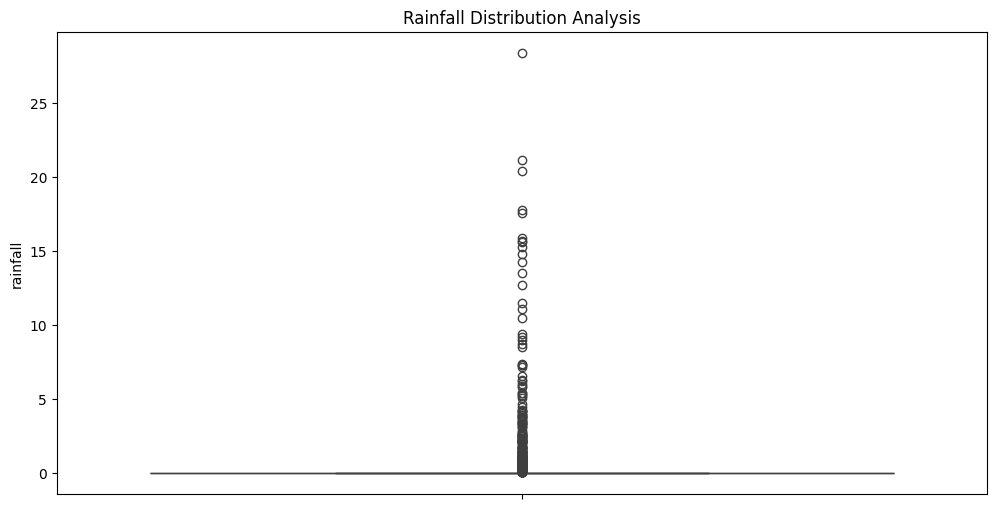

In [55]:
plt.figure(figsize=(12,6))
sns.boxplot(matches['rainfall'])
plt.title('Rainfall Distribution Analysis')
plt.show()

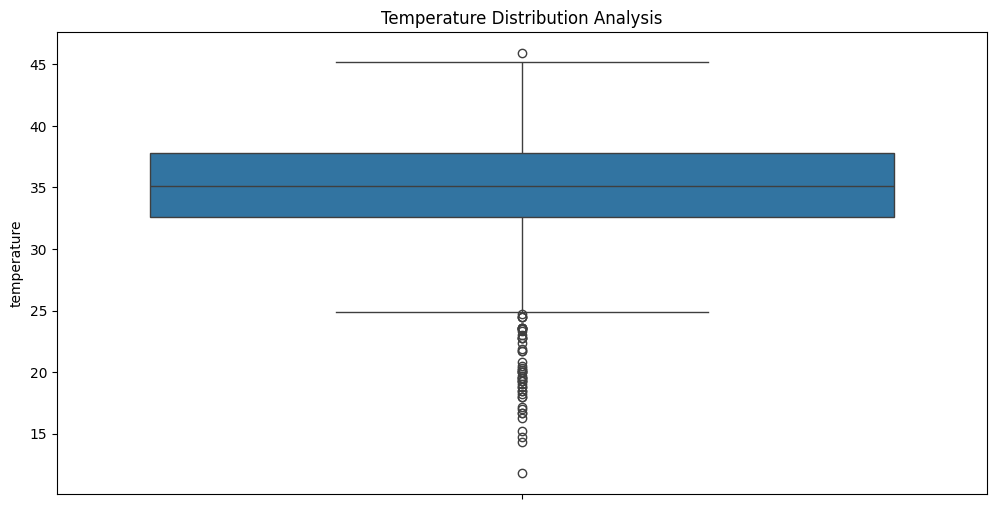

In [56]:
plt.figure(figsize=(12,6))
sns.boxplot(matches['temperature'])
plt.title('Temperature Distribution Analysis')
plt.show()

In [57]:
print(matches[matches['temperature']<20][['city','date','temperature']])

               city       date  temperature
58        Cape Town 2009-04-18         19.3
59        Cape Town 2009-04-18         19.3
60        Cape Town 2009-04-19         18.0
61        Cape Town 2009-04-19         18.0
62   Port Elizabeth 2009-04-20         17.0
63           Durban 2009-04-21         18.5
66        Cape Town 2009-04-23         17.2
80   Port Elizabeth 2009-05-02         19.3
81     Johannesburg 2009-05-02         18.5
82   Port Elizabeth 2009-05-03         18.8
83     Johannesburg 2009-05-03         16.3
94     Johannesburg 2009-05-10         14.7
96        Centurion 2009-05-12         19.5
97        Centurion 2009-05-12         19.5
103    Johannesburg 2009-05-16         15.2
104    Johannesburg 2009-05-17         14.3
105    Bloemfontein 2009-05-17         11.8
106       Centurion 2009-05-18         19.7
107    Johannesburg 2009-05-19         18.8
110       Centurion 2009-05-21         16.7
111       Centurion 2009-05-21         16.7
112       Centurion 2009-05-22  

city
Abu Dhabi         34.908108
Ahmedabad         39.583333
Bangalore         32.813187
Bloemfontein      16.050000
Cape Town         19.328571
Centurion         20.941667
Chandigarh        35.040984
Chennai           35.025882
Cuttack           38.228571
Delhi             37.332584
Dharamsala        28.500000
Dubai             35.678261
Durban            24.280000
East London       22.833333
Guwahati          31.333333
Hyderabad         37.355844
Indore            39.100000
Jaipur            37.907018
Johannesburg      16.875000
Kanpur            40.650000
Kimberley         20.633333
Kochi             30.680000
Kolkata           35.422581
Lucknow           37.192308
Mohali            32.500000
Mumbai            32.945055
Nagpur            41.800000
Port Elizabeth    19.928571
Pune              37.752941
Raipur            40.683333
Rajkot            38.290000
Ranchi            38.057143
Sharjah           35.557143
Visakhapatnam     33.540000
Name: temperature, dtype: float64


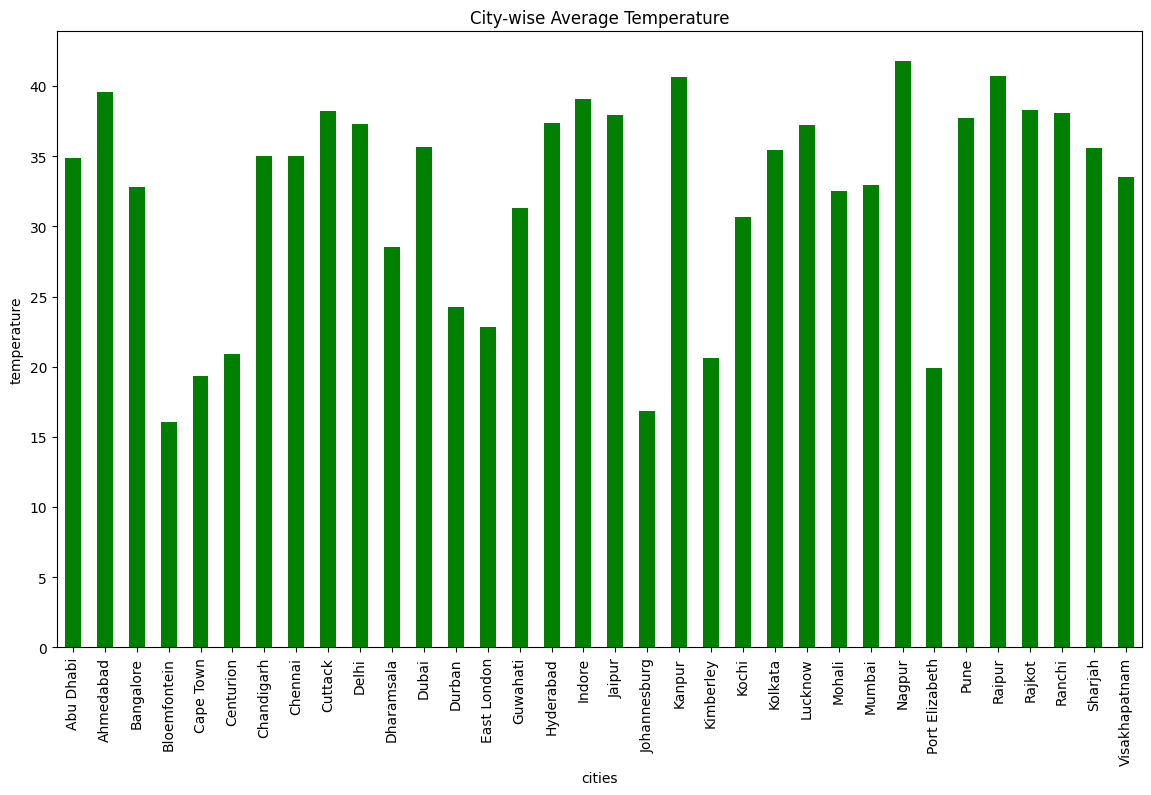

In [58]:
citywise_temp=matches.groupby('city')['temperature'].mean()
print(citywise_temp)
plt.figure(figsize=(14,8))
citywise_temp.plot(kind='bar',color='green')
plt.title('City-wise Average Temperature')
plt.ylabel('temperature')
plt.xlabel('cities')
plt.show()

In [59]:
toss_decision_temp_based=matches.groupby('toss_decision')['temperature'].mean()

print(toss_decision_temp_based)

toss_decision
bat      34.739487
field    34.624000
Name: temperature, dtype: float64


In [60]:
hot_matches=matches[matches['temperature']>25]
winter_matches=matches[matches['temperature']<=25]
print(hot_matches.shape)
print(winter_matches.shape)

(1038, 23)
(52, 23)


In [61]:
hot_matches = matches[matches['temperature'] >= 35]
cool_matches = matches[matches['temperature'] < 25]

print(hot_matches['toss_decision'].value_counts(normalize=True))
print(cool_matches['toss_decision'].value_counts(normalize=True))

toss_decision
field    0.6
bat      0.4
Name: proportion, dtype: float64
toss_decision
bat      0.596154
field    0.403846
Name: proportion, dtype: float64


In [62]:
print(matches['method'].count())

check_dls_use_when_rain=matches.groupby('method')['rainfall'].count()
print(check_dls_use_when_rain)

21
method
D/L    21
Name: rainfall, dtype: int64


In [63]:
# !pip install streamlit

In [64]:
print(matches['season'].unique())

<ArrowStringArray>
['2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016',
 '2017', '2018', '2019', '2021', '2022', '2023', '2024']
Length: 16, dtype: str


In [65]:
# matches.to_csv('ipl_dashboard_final.csv', index=False)
# print("Saved!")